# Project Name: SubscriTrack: Subscription Revenue & Churn Analyzer
STEP1: ABOUT THE PROJECT

Problem Statement: Subscription-based businesses struggle to track revenue trends and reduce churn (customers leaving subscriptions). Without proper analysis, it becomes difficult to identify weak areas and improve customer retention.

Solution: Develop a data-driven analyzer that uses Python libraries to analyze subscription revenue, churn rate, customer lifetime value, and monthly recurring revenue, and visualize the insights for better decision-making.

Expected Outcomes: Clear understanding of revenue trends over time. Identification of high churn customer segments. Actionable business insights to reduce churn and boost revenue.

STEP2: KPI (Key Performance Indicators):
1. Monthly Recurring Revenue (MRR): Total subscription revenue earned each month.
2. Customer Churn Rate: Percentage of customers who cancel in a given period.
3. Revenue Churn Rate: Percentage of revenue lost due to cancellations.
4. Average Revenue per User (ARPU): Average revenue generated by each active customer.
5. Active vs Churned Customers: Comparison between ongoing subscribers and those who left.

STEP3: DATA COLLECTION

In [1]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the Telco Customer Churn dataset
df = pd.read_csv("Telco-Customer-Churn.csv")

In [3]:
# Display first 5 rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Oveview of dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


STEP4: DATA CLEANING AND PREPROCESSING

In [7]:
# Check missing values
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
# Convert TotalCharges to numeric (if not already)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors='coerce')

In [9]:
# Check for duplicates
df.duplicated().sum()

np.int64(0)

In [10]:
# Remove duplicates if any
df.drop_duplicates(inplace=True)

In [11]:
# Convert categorical columns to proper format
categorical_cols = [
    "gender", "SeniorCitizen", "Partner", "Dependents", "PhoneService", "MultipleLines",
    "InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport",
    "StreamingTV", "StreamingMovies", "Contract", "PaperlessBilling", "PaymentMethod", "Churn"
]

for col in categorical_cols:
    df[col] = df[col].astype('category')

In [12]:
# Churn Flag
df["Churn_Flag"] = df["Churn"].apply(lambda x: 1 if x == "Yes" else 0)

# Create tenure groups
bins = [0, 12, 24, 48, 60, 72]
labels = ["0-12","13-24","25-48","49-60","61-72"]
df["Tenure_Group"] = pd.cut(df["tenure"], bins=bins, labels=labels)


In [13]:
# Check data types
df.dtypes

customerID               str
gender              category
SeniorCitizen       category
Partner             category
Dependents          category
tenure                 int64
PhoneService        category
MultipleLines       category
InternetService     category
OnlineSecurity      category
OnlineBackup        category
DeviceProtection    category
TechSupport         category
StreamingTV         category
StreamingMovies     category
Contract            category
PaperlessBilling    category
PaymentMethod       category
MonthlyCharges       float64
TotalCharges         float64
Churn               category
Churn_Flag          category
Tenure_Group        category
dtype: object

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   customerID        7043 non-null   str     
 1   gender            7043 non-null   category
 2   SeniorCitizen     7043 non-null   category
 3   Partner           7043 non-null   category
 4   Dependents        7043 non-null   category
 5   tenure            7043 non-null   int64   
 6   PhoneService      7043 non-null   category
 7   MultipleLines     7043 non-null   category
 8   InternetService   7043 non-null   category
 9   OnlineSecurity    7043 non-null   category
 10  OnlineBackup      7043 non-null   category
 11  DeviceProtection  7043 non-null   category
 12  TechSupport       7043 non-null   category
 13  StreamingTV       7043 non-null   category
 14  StreamingMovies   7043 non-null   category
 15  Contract          7043 non-null   category
 16  PaperlessBilling  7043 non-null   c

In [15]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_Flag,Tenure_Group
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0,0-12
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,One year,No,Mailed check,56.95,1889.50,No,0,25-48
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,0-12
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0,25-48
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,0-12


STEP5: EXPLORATORY DATA ANALYSIS (EDA)

In [16]:
# Shape of dataset
print("Rows:", df.shape[0], " Columns:", df.shape[1])

Rows: 7043  Columns: 23


In [17]:
# Stats
df.describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7032.000000
mean,32.371149,64.761692,2283.300441
std,24.559481,30.090047,2266.771362
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.850000,3794.737500
max,72.000000,118.750000,8684.800000


In [18]:
# Count of churned vs active
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [19]:
# Unique Values in Categorical Columns
categorical_cols = ["gender", "SeniorCitizen", "Partner", "Dependents", 
                    "PhoneService", "InternetService", "Contract", "PaymentMethod"]

for col in categorical_cols:
    print(f"\nUnique values in {col}: {df[col].unique()}")


Unique values in gender: ['Female', 'Male']
Categories (2, str): ['Female', 'Male']

Unique values in SeniorCitizen: [0, 1]
Categories (2, int64): [0, 1]

Unique values in Partner: ['Yes', 'No']
Categories (2, str): ['No', 'Yes']

Unique values in Dependents: ['No', 'Yes']
Categories (2, str): ['No', 'Yes']

Unique values in PhoneService: ['No', 'Yes']
Categories (2, str): ['No', 'Yes']

Unique values in InternetService: ['DSL', 'Fiber optic', 'No']
Categories (3, str): ['DSL', 'Fiber optic', 'No']

Unique values in Contract: ['Month-to-month', 'One year', 'Two year']
Categories (3, str): ['Month-to-month', 'One year', 'Two year']

Unique values in PaymentMethod: ['Electronic check', 'Mailed check', 'Bank transfer (automatic)', 'Credit card (automatic)']
Categories (4, str): ['Bank transfer (automatic)', 'Credit card (automatic)', 'Electronic check', 'Mailed check']


STEP6: CHURN AND REVENUE ANALYSIS

In [20]:
# 1.  Monthly Recurring Revenue (MRR)
# MRR = sum of MonthlyCharges for active customers
active_customers = df[df["Churn_Flag"] == 0]
MRR = active_customers["MonthlyCharges"].sum()
print("Monthly Recurring Revenue (MRR):", round(MRR, 2))

Monthly Recurring Revenue (MRR): 316985.75


In [21]:
# 2. Customer Churn Rate
# Churn Rate = (Number of Cancelled Customers / Total Customers) * 100
df["Churn_Flag"] = df["Churn_Flag"].astype(int)
total_customers = df.shape[0]
churned_customers = df["Churn_Flag"].sum()
churn_rate = (churned_customers / total_customers) * 100
print("Customer Churn Rate (%):", round(churn_rate, 2))

Customer Churn Rate (%): 26.54


In [22]:
# 3. Revenue Churn Rate
# Revenue Churn Rate= ( Revenue lost from cancelled customers / Total Revenue ) * 100
revenue_lost = df[df["Churn_Flag"] == 1]["MonthlyCharges"].sum()
total_revenue = df["MonthlyCharges"].sum()
revenue_churn_rate = (revenue_lost / total_revenue) * 100
print("Revenue Churn Rate (%):", round(revenue_churn_rate, 2))

Revenue Churn Rate (%): 30.5


In [23]:
# 4. Average Revenue per User (ARPU)
# ARPU = Total Revenue / Number of Active Customers
ARPU = active_customers["MonthlyCharges"].mean()
print("Average Revenue per User (ARPU):", round(ARPU, 2))

Average Revenue per User (ARPU): 61.27


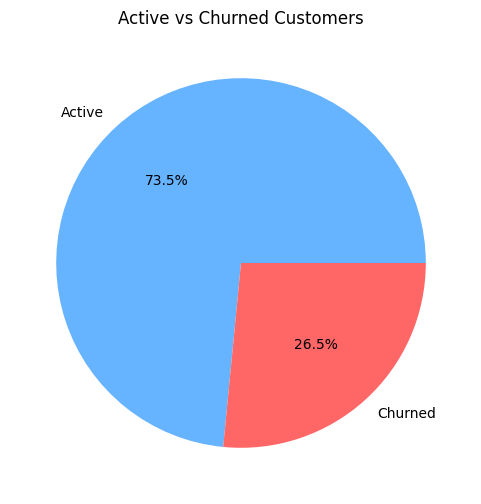

In [24]:
# 5. Active vs Churned Customers
active_count = total_customers - churned_customers
labels = ['Active', 'Churned']
sizes = [active_count, churned_customers]
plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=['#66b3ff','#ff6666'])
plt.title("Active vs Churned Customers")
plt.show()

STEP7: ADVANCED INSIGHTS

In [25]:
# Percentage of churn in each contract type
contract_churn = df.groupby("Contract")["Churn_Flag"].mean() * 100
print("Churn Rate by Contract Type (%):\n", contract_churn)

Churn Rate by Contract Type (%):
 Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn_Flag, dtype: float64


In [26]:
# Percentage of churn by tenure group (if Tenure_Group exists)
tenure_churn = df.groupby("Tenure_Group")["Churn_Flag"].mean() * 100
print("\nChurn Rate by Tenure Group (%):\n", tenure_churn)


Churn Rate by Tenure Group (%):
 Tenure_Group
0-12     47.678161
13-24    28.710938
25-48    20.388959
49-60    14.423077
61-72     6.609808
Name: Churn_Flag, dtype: float64


In [27]:
# Average MonthlyCharges for churned vs active
avg_revenue = df.groupby("Churn")["MonthlyCharges"].mean()
print("\nAverage Monthly Charges by Churn Status:\n", avg_revenue)


Average Monthly Charges by Churn Status:
 Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64


In [28]:
# Total revenue lost due to churn
revenue_lost = df[df["Churn_Flag"]==1]["MonthlyCharges"].sum()
print("\nTotal Revenue Lost from Churned Customers:", revenue_lost)


Total Revenue Lost from Churned Customers: 139130.85


In [29]:
# Customer Segmentation: High-risk customers: month-to-month contracts, short tenure, high MonthlyCharges.
high_risk = df[(df["Contract"]=="Month-to-month") & (df["Churn_Flag"]==1)]
print("High-risk churned customers sample:\n", high_risk.head())

High-risk churned customers sample:
     customerID  gender SeniorCitizen Partner Dependents  tenure PhoneService  \
2   3668-QPYBK    Male             0      No         No       2          Yes   
4   9237-HQITU  Female             0      No         No       2          Yes   
5   9305-CDSKC  Female             0      No         No       8          Yes   
8   7892-POOKP  Female             0     Yes         No      28          Yes   
13  0280-XJGEX    Male             0      No         No      49          Yes   

   MultipleLines InternetService OnlineSecurity  ... StreamingTV  \
2             No             DSL            Yes  ...          No   
4             No     Fiber optic             No  ...          No   
5            Yes     Fiber optic             No  ...         Yes   
8            Yes     Fiber optic             No  ...         Yes   
13           Yes     Fiber optic             No  ...         Yes   

   StreamingMovies        Contract PaperlessBilling  \
2               No

In [30]:
# Churn Rate by Payment Method
payment_churn = df.groupby("PaymentMethod")["Churn_Flag"].mean() * 100
print("\nChurn Rate by Payment Method (%):\n", payment_churn)


Churn Rate by Payment Method (%):
 PaymentMethod
Bank transfer (automatic)    16.709845
Credit card (automatic)      15.243101
Electronic check             45.285412
Mailed check                 19.106700
Name: Churn_Flag, dtype: float64


STEP8: VISUALIZATIONS

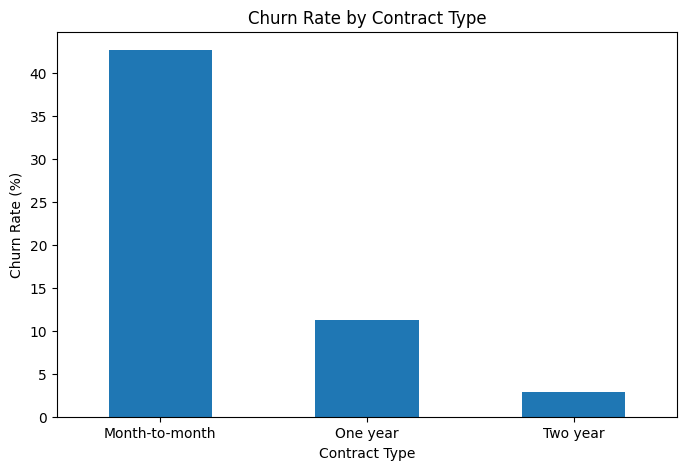

In [31]:
# Percentage of churn in each contract type
plt.figure(figsize=(8,5))
contract_churn.plot(kind='bar')

plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.title("Churn Rate by Contract Type")
plt.xticks(rotation=0)

plt.show()

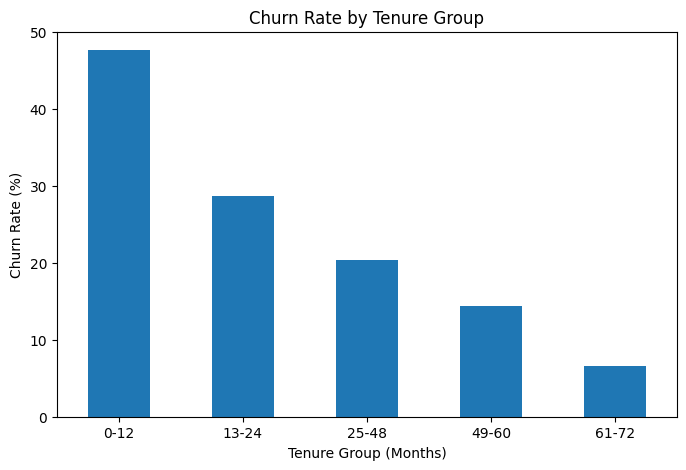

In [32]:
# Percentage of churn by tenure group (if Tenure_Group exists)
plt.figure(figsize=(8,5))
tenure_churn.plot(kind='bar')

plt.xlabel("Tenure Group (Months)")
plt.ylabel("Churn Rate (%)")
plt.title("Churn Rate by Tenure Group")
plt.xticks(rotation=0)

plt.show()

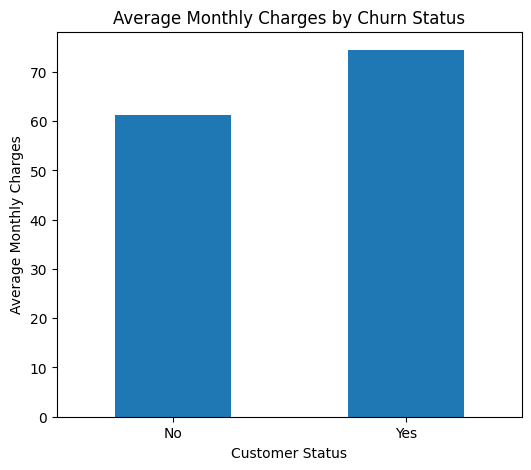

In [33]:
# Average MonthlyCharges for churned vs active
avg_revenue = df.groupby("Churn")["MonthlyCharges"].mean()

plt.figure(figsize=(6,5))
avg_revenue.plot(kind='bar')

plt.xlabel("Customer Status")
plt.ylabel("Average Monthly Charges")
plt.title("Average Monthly Charges by Churn Status")
plt.xticks(rotation=0)

plt.show()

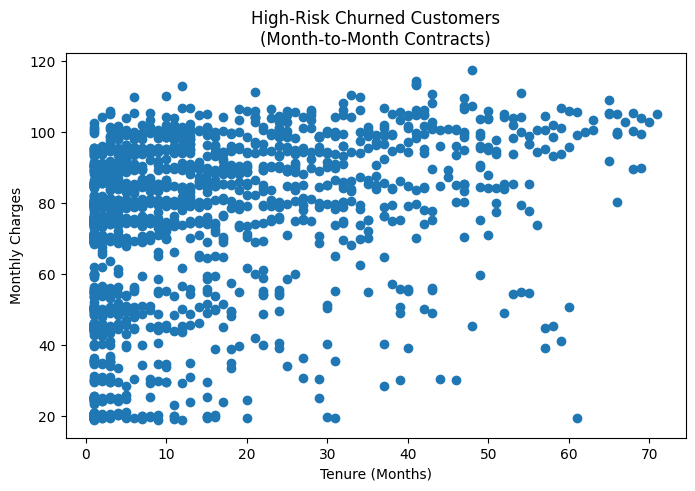

In [34]:
# Customer Segmentation: High-risk customers: month-to-month contracts, short tenure, high MonthlyCharges.
high_risk = df[(df["Contract"] == "Month-to-month") & (df["Churn_Flag"] == 1)]

plt.figure(figsize=(8,5))
plt.scatter(high_risk["tenure"], high_risk["MonthlyCharges"])

plt.xlabel("Tenure (Months)")
plt.ylabel("Monthly Charges")
plt.title("High-Risk Churned Customers\n(Month-to-Month Contracts)")

plt.show()

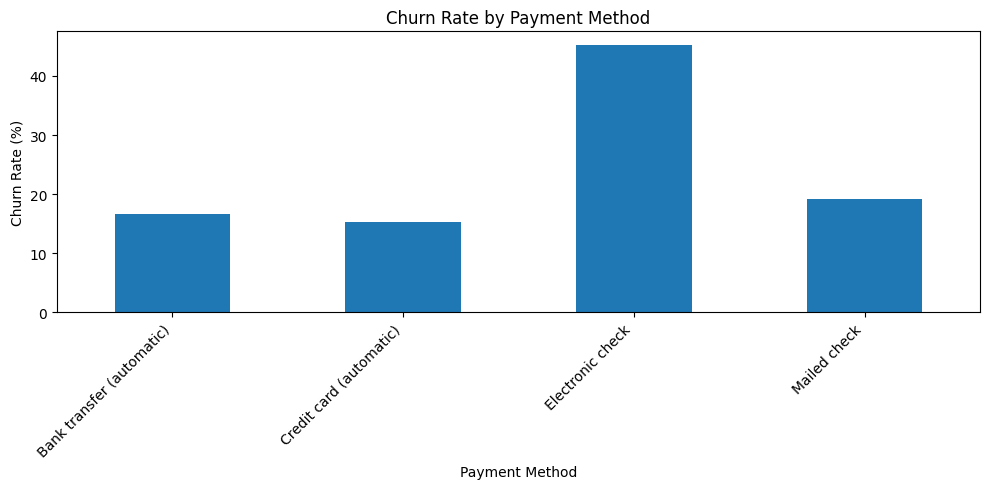

In [35]:
# Churn Rate by Payment Method
plt.figure(figsize=(10,5))
payment_churn.plot(kind='bar')

plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.title("Churn Rate by Payment Method")
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()